# Modèle 1 — Principal Component Regression (PCR)
**Projet ML 2026 — UMONS | Groupe 3**

La PCR combine deux étapes :
1. **PCA** (Principal Component Analysis) → réduit la dimensionnalité des features
2. **Régression linéaire** → prédit `Ja in Prozent` sur les composantes principales

C'est particulièrement utile ici car nos features sont nombreuses (67) et potentiellement corrélées entre elles.

In [1]:
# Imports et configuration
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.impute import SimpleImputer

# Import des fonctions utilitaires du projet
sys.path.append("../src")
from utils import compute_rmse, print_cv_results, create_submission

pd.set_option('display.float_format', '{:.4f}'.format)

# Chargement des données finales (nettoyées et fusionnées dans 01_EDA.ipynb)
train = pd.read_csv("../data/train_final.csv")
test  = pd.read_csv("../data/test_final.csv")

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

Train : (1559, 67)
Test  : (669, 66)


In [2]:
# Séparation features / cible
y = train["Ja in Prozent"]

# One Hot Encoding sur Kanton
train_encoded = pd.get_dummies(train, columns=["Kanton"])
test_encoded  = pd.get_dummies(test,  columns=["Kanton"])

# Suppression des colonnes inutiles pour la modélisation
drop_cols = ["Ja in Prozent", "Gemeinde", "commune_id", "Kantons-Nummer"]
X      = train_encoded.drop(columns=[c for c in drop_cols if c in train_encoded.columns])
X_test = test_encoded.drop(columns=[c for c in drop_cols if c in test_encoded.columns])

# Alignement des colonnes train et test
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print(f"X train : {X.shape}")
print(f"X test  : {X_test.shape}")
print(f"y train : {y.shape}")

X train : (1559, 88)
X test  : (669, 88)
y train : (1559,)


## Modèle PCR

In [3]:
# Définition du pipeline PCR
pipeline = Pipeline([
    ("imputer",   SimpleImputer(strategy="mean")),
    ("scaler",    StandardScaler()),
    ("pca",       PCA(n_components=10)),
    ("regression", LinearRegression())
])

# Cross-validation 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    pipeline, X, y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

# Affichage des résultats via utils
print_cv_results(-scores, model_name="PCR (n_components=10)")

=== PCR (n_components=10) — Cross-Validation (5 folds) ===
RMSE par fold : [8.6101 7.3708 7.8307 7.41   7.1383]
RMSE moyen    : 7.6720
RMSE std      : 0.5195


## Optimisation du nombre de composantes
On teste différentes valeurs de n_components pour trouver le meilleur RMSE.

Meilleur n_components : 69
Meilleur RMSE CV      : 6.3850


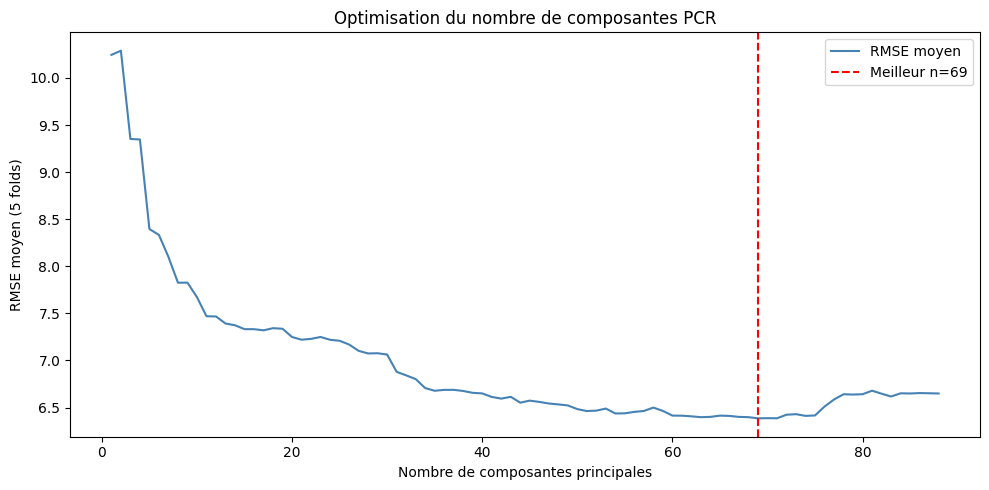

In [4]:
# Optimisation du nombre de composantes principales
n_components_range = range(1, min(X.shape[0], X.shape[1]) + 1)
rmse_means = []
rmse_stds  = []

for n in n_components_range:
    pipeline = Pipeline([
        ("imputer",    SimpleImputer(strategy="mean")),
        ("scaler",     StandardScaler()),
        ("pca",        PCA(n_components=n)),
        ("regression", LinearRegression())
    ])
    scores = cross_val_score(
        pipeline, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )
    rmse_means.append(-scores.mean())
    rmse_stds.append(scores.std())

# Meilleur n_components
best_n    = n_components_range[np.argmin(rmse_means)]
best_rmse = min(rmse_means)
print(f"Meilleur n_components : {best_n}")
print(f"Meilleur RMSE CV      : {best_rmse:.4f}")

# Visualisation
plt.figure(figsize=(10, 5))
plt.plot(n_components_range, rmse_means, color="steelblue", label="RMSE moyen")
plt.axvline(best_n, color="red", linestyle="--", label=f"Meilleur n={best_n}")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("RMSE moyen (5 folds)")
plt.title("Optimisation du nombre de composantes PCR")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/pcr_n_components.png", dpi=150, bbox_inches="tight")
plt.show()

##  Entraînement du modèle final
On entraîne le modèle PCR avec le meilleur n_components trouvé.

In [5]:
# Entraînement du modèle final avec le meilleur n_components
pipeline_final = Pipeline([
    ("imputer",    SimpleImputer(strategy="mean")),
    ("scaler",     StandardScaler()),
    ("pca",        PCA(n_components=best_n)),
    ("regression", LinearRegression())
])

pipeline_final.fit(X, y)

# Evaluation sur le train complet
y_pred_train = pipeline_final.predict(X)
rmse_train   = compute_rmse(y, y_pred_train)

print(f"✅ Modèle PCR entraîné avec n_components={best_n}")
print(f"RMSE train complet    : {rmse_train:.4f}")
print(f"RMSE cross-validation : {best_rmse:.4f}")

✅ Modèle PCR entraîné avec n_components=69
RMSE train complet    : 5.9546
RMSE cross-validation : 6.3850


## Prédictions et soumission Kaggle

In [6]:
# Prédictions sur le test
y_pred_test = pipeline_final.predict(X_test)

# Création du fichier de soumission
create_submission(
    commune_ids=test["commune_id"],
    y_pred=y_pred_test,
    filename="../submissions/submission_PCR_v1.csv"
)

✅ Soumission créée : ../submissions/submission_PCR_v1.csv (669 lignes)


,Id,Predicted
0,69,48.0038
1,981,37.8221
2,5432,35.0985
3,387,46.1521
4,2194,28.1287
...,...,...
664,4080,39.7922
665,5425,38.6167
666,5199,48.0270
667,4251,34.4008
